In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("All imports successful.")

All imports successful.


Reads all 22 Wind Farm A CSV files and combines them into one DataFrame with event labels joined. 

In [16]:
# UPDATE THIS PATH to wherever you saved the Wind Farm A folder
base_path     = "C:/Users/cjcha/Downloads/CARE_To_Compare/CARE_To_Compare/Wind Farm A"
datasets_path = f"{base_path}/datasets"

# Load event labels
event_info = pd.read_csv(f"{base_path}/event_info.csv", sep=";")

# Load all 22 CSVs and combine
dfs = []
for fname in os.listdir(datasets_path):
    if fname.endswith(".csv"):
        df_temp             = pd.read_csv(os.path.join(datasets_path, fname), sep=";")
        df_temp["event_id"] = int(fname.replace(".csv", ""))
        dfs.append(df_temp)

df_raw = pd.concat(dfs, ignore_index=True)

# Join labels
df_raw["event_id"] = df_raw["event_id"].astype(int)
df_raw = df_raw.merge(
    event_info[["event_id", "event_label", "event_description"]],
    on="event_id", how="left"
)

# Binary label: 1 = anomaly, 0 = normal
df_raw["label"] = (df_raw["event_label"] == "anomaly").astype(int)

print(f"Rows:    {len(df_raw):,}")
print(f"Columns: {len(df_raw.columns)}")
print(f"\nLabel distribution:")
print(df_raw["label"].value_counts())

Rows:    1,196,747
Columns: 90

Label distribution:
label
1    649789
0    546958
Name: count, dtype: int64


In [17]:
# Add more sensors for more accuracy
base_sensors = [
    # Original five
    "sensor_12_avg",    # gearbox oil temperature
    "sensor_11_avg",    # gearbox bearing temperature
    "sensor_13_avg",    # generator bearing temperature
    "sensor_18_avg",    # generator RPM
    "wind_speed_3_avg", # wind speed

    # New additions
    "sensor_41_avg",    # hydraulic group oil temperature — most common fault
    "sensor_15_avg",    # generator stator winding phase 1
    "sensor_16_avg",    # generator stator winding phase 2
    "sensor_17_avg",    # generator stator winding phase 3
    "sensor_38_avg",    # HV transformer phase L1
    "sensor_39_avg",    # HV transformer phase L2
    "sensor_40_avg",    # HV transformer phase L3
    "sensor_43_avg",    # nacelle temperature
    "sensor_52_avg",    # rotor RPM
    "power_29_avg",     # active power output
    "reactive_power_27_avg",  # reactive power
]

existing = [f for f in base_sensors if f in df_raw.columns]
missing  = [f for f in base_sensors if f not in df_raw.columns]

print(f"Base sensors found:   {existing}")
if missing:
    print(f"Base sensors missing: {missing}")

Base sensors found:   ['sensor_12_avg', 'sensor_11_avg', 'sensor_13_avg', 'sensor_18_avg', 'wind_speed_3_avg', 'sensor_41_avg', 'sensor_15_avg', 'sensor_16_avg', 'sensor_17_avg', 'sensor_38_avg', 'sensor_39_avg', 'sensor_40_avg', 'sensor_43_avg', 'sensor_52_avg', 'power_29_avg', 'reactive_power_27_avg']


Separates training rows from prediction rows before any feature engineering to prevent data leakage.

In [18]:
# Split before engineering so rolling windows never cross the boundary
train_df = df_raw[df_raw["train_test"] == "train"].copy()
pred_df  = df_raw[df_raw["train_test"] == "prediction"].copy()

print(f"Training rows:   {len(train_df):,}")
print(f"Prediction rows: {len(pred_df):,}")
print(f"\nTraining anomaly rate: {train_df['label'].mean()*100:.1f}%")

Training rows:   1,146,154
Prediction rows: 50,593

Training anomaly rate: 54.6%


In [19]:
# Same feature engineering as the previous notebook
# Rolling mean, rolling std, delta, and z-score per sensor

def engineer_features(df, feature_cols):
    """Add rolling, delta and z-score features per turbine per event."""
    df     = df.sort_values(["asset_id", "event_id", "time_stamp"]).copy()
    groups = df.groupby(["asset_id", "event_id"])

    for col in feature_cols:
        df[f"{col}_roll_mean_6h"] = groups[col].transform(
            lambda x: x.rolling(36, min_periods=1).mean()
        )
        df[f"{col}_roll_std_6h"] = groups[col].transform(
            lambda x: x.rolling(36, min_periods=1).std()
        )
        df[f"{col}_roll_mean_24h"] = groups[col].transform(
            lambda x: x.rolling(144, min_periods=1).mean()
        )
        df[f"{col}_delta"] = groups[col].transform(
            lambda x: x.diff()
        )

    return df


print("Engineering rolling and delta features...")
df_train_eng = engineer_features(train_df, existing)
df_pred_eng  = engineer_features(pred_df,  existing)

# Compute z-score baseline from training data only
print("Computing z-score baselines...")
baseline = (
    df_train_eng
    .groupby(["asset_id", "event_id"])[existing]
    .agg(["mean", "std"])
)
baseline.columns = [f"{col}_{stat}" for col, stat in baseline.columns]
baseline         = baseline.reset_index()

df_train_eng = df_train_eng.merge(baseline, on=["asset_id", "event_id"], how="left")
df_pred_eng  = df_pred_eng.merge(baseline,  on=["asset_id", "event_id"], how="left")

for col in existing:
    for df_eng in [df_train_eng, df_pred_eng]:
        df_eng[f"{col}_zscore"] = (
            (df_eng[col] - df_eng[f"{col}_mean"]) /
            df_eng[f"{col}_std"].replace(0, 1)
        )

print(f"Feature engineering complete.")
print(f"Columns after engineering: {len(df_train_eng.columns)}")

Engineering rolling and delta features...
Computing z-score baselines...
Feature engineering complete.
Columns after engineering: 202


Assembles the final list of all engineered feature names and builds the X_train, X_pred, y_train, y_pred_true arrays for modelling.

In [20]:
engineered_features = (
    existing +
    [f"{c}_roll_mean_6h"  for c in existing] +
    [f"{c}_roll_std_6h"   for c in existing] +
    [f"{c}_roll_mean_24h" for c in existing] +
    [f"{c}_delta"         for c in existing] +
    [f"{c}_zscore"        for c in existing]
)

X_train     = df_train_eng[engineered_features].fillna(0)
y_train     = df_train_eng["label"].values
X_pred      = df_pred_eng[engineered_features].fillna(0)
y_pred_true = df_pred_eng["label"].values

print(f"Base sensors:              {len(existing)}")
print(f"Total engineered features: {len(engineered_features)}")
print(f"\nTraining rows:   {len(X_train):,}")
print(f"Prediction rows: {len(X_pred):,}")

Base sensors:              16
Total engineered features: 96

Training rows:   1,146,154
Prediction rows: 50,593


In [21]:
# Random Forest builds many decision trees and combines their votes
#
# n_estimators=200
#   How many trees to build. More = better but slower.
#   200 is a good balance for this dataset size.
#
# max_depth=10
#   How deep each tree can grow. Deeper = more complex patterns learned
#   but also more risk of memorising the training data (overfitting).
#   10 is a reasonable starting point, we can tune this later.
#
# class_weight="balanced"
#   Since anomalies are rare, this tells the model to treat each anomaly
#   row as more important than a normal row, same idea as scale_pos_weight
#   in XGBoost. Without this the model would just predict "normal" always.
#
# random_state=42
#   Makes results reproducible
#
# n_jobs=-1
#   Use all available CPU cores to train trees in parallel — faster.

print("Training Random Forest...")
print("(This may take 1-2 minutes with 200 trees)")

rf_model = RandomForestClassifier(
    n_estimators  = 200,
    max_depth     = 10,
    class_weight  = "balanced",
    random_state  = 42,
    n_jobs        = -1
)

rf_model.fit(X_train, y_train)

print("Training complete.")
print(f"Trees built: {rf_model.n_estimators}")

Training Random Forest...
(This may take 1-2 minutes with 200 trees)
Training complete.
Trees built: 200


In [22]:
# predict       -> binary 0 or 1 per row
# predict_proba -> probability between 0-1 per row (more useful)

rf_preds = rf_model.predict(X_pred)
rf_probs = rf_model.predict_proba(X_pred)[:, 1]
rf_acc   = accuracy_score(y_pred_true, rf_preds)

print(f"Accuracy: {rf_acc*100:.1f}%")
print("\nDetailed breakdown:")
print(classification_report(
    y_pred_true, rf_preds,
    target_names=["Normal (0)", "Anomaly (1)"]
))

Accuracy: 75.3%

Detailed breakdown:
              precision    recall  f1-score   support

  Normal (0)       0.87      0.61      0.72     26064
 Anomaly (1)       0.69      0.91      0.78     24529

    accuracy                           0.75     50593
   macro avg       0.78      0.76      0.75     50593
weighted avg       0.78      0.75      0.75     50593



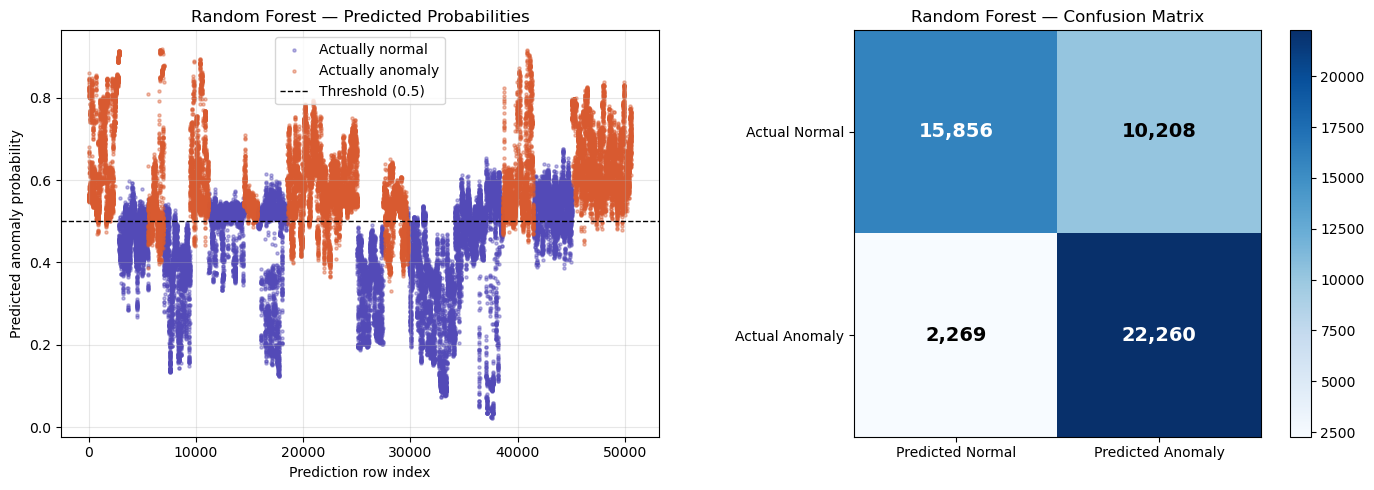


True Positives  (anomaly correctly flagged): 22,260
True Negatives  (normal correctly ignored):  15,856
False Positives (false alarms):              10,208
False Negatives (missed faults):             2,269


In [23]:
#Visualises predicted probabilities coloured by true label and shows a confusion matrix with the exact counts of correct and incorrect predictions.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

normal_mask  = y_pred_true == 0
anomaly_mask = y_pred_true == 1

# Left: predicted probabilities
axes[0].scatter(
    np.where(normal_mask)[0],  rf_probs[normal_mask],
    color="#534AB7", alpha=0.4, s=5, label="Actually normal"
)
axes[0].scatter(
    np.where(anomaly_mask)[0], rf_probs[anomaly_mask],
    color="#D85A30", alpha=0.4, s=5, label="Actually anomaly"
)
axes[0].axhline(y=0.5, color="black", linestyle="--",
                linewidth=1, label="Threshold (0.5)")
axes[0].set_xlabel("Prediction row index")
axes[0].set_ylabel("Predicted anomaly probability")
axes[0].set_title("Random Forest — Predicted Probabilities")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Right: confusion matrix
cm = confusion_matrix(y_pred_true, rf_preds)
im = axes[1].imshow(cm, cmap="Blues")
axes[1].set_xticks([0, 1])
axes[1].set_yticks([0, 1])
axes[1].set_xticklabels(["Predicted Normal", "Predicted Anomaly"])
axes[1].set_yticklabels(["Actual Normal", "Actual Anomaly"])
axes[1].set_title("Random Forest — Confusion Matrix")
for i in range(2):
    for j in range(2):
        axes[1].text(
            j, i, f"{cm[i,j]:,}", ha="center", va="center",
            color="white" if cm[i,j] > cm.max()/2 else "black",
            fontsize=14, fontweight="bold"
        )
plt.colorbar(im, ax=axes[1])
plt.tight_layout()
plt.savefig("rf_results.png", dpi=150, bbox_inches="tight")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Positives  (anomaly correctly flagged): {tp:,}")
print(f"True Negatives  (normal correctly ignored):  {tn:,}")
print(f"False Positives (false alarms):              {fp:,}")
print(f"False Negatives (missed faults):             {fn:,}")

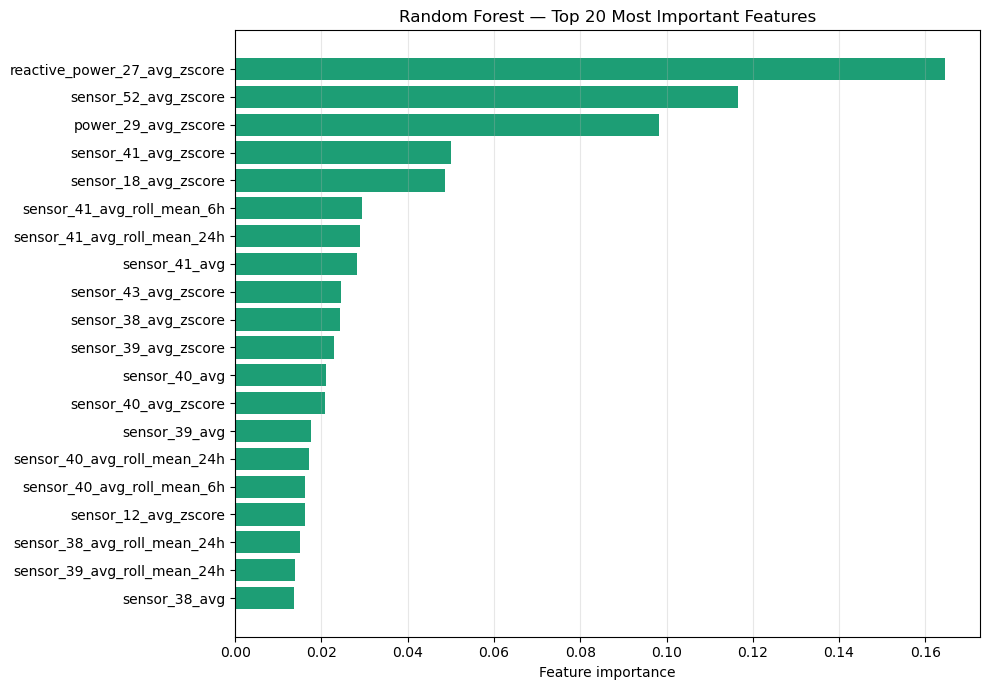

Top 10 most important features:
                     feature  importance
reactive_power_27_avg_zscore    0.164453
        sensor_52_avg_zscore    0.116593
         power_29_avg_zscore    0.098293
        sensor_41_avg_zscore    0.050013
        sensor_18_avg_zscore    0.048565
  sensor_41_avg_roll_mean_6h    0.029450
 sensor_41_avg_roll_mean_24h    0.028926
               sensor_41_avg    0.028139
        sensor_43_avg_zscore    0.024565
        sensor_38_avg_zscore    0.024256


In [24]:
# Each feature gets a score showing how useful it was across all 200 trees.
# Higher = more useful for separating anomalies from normal readings.

importance_df = pd.DataFrame({
    "feature":    engineered_features,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

# Plot top 20
top20 = importance_df.head(20)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(
    top20["feature"][::-1],
    top20["importance"][::-1],
    color="#1D9E75", edgecolor="none"
)
ax.set_xlabel("Feature importance")
ax.set_title("Random Forest — Top 20 Most Important Features")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("rf_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top 10 most important features:")
print(importance_df[["feature", "importance"]].head(10).to_string(index=False))

First detection: 48.0 hours before fault


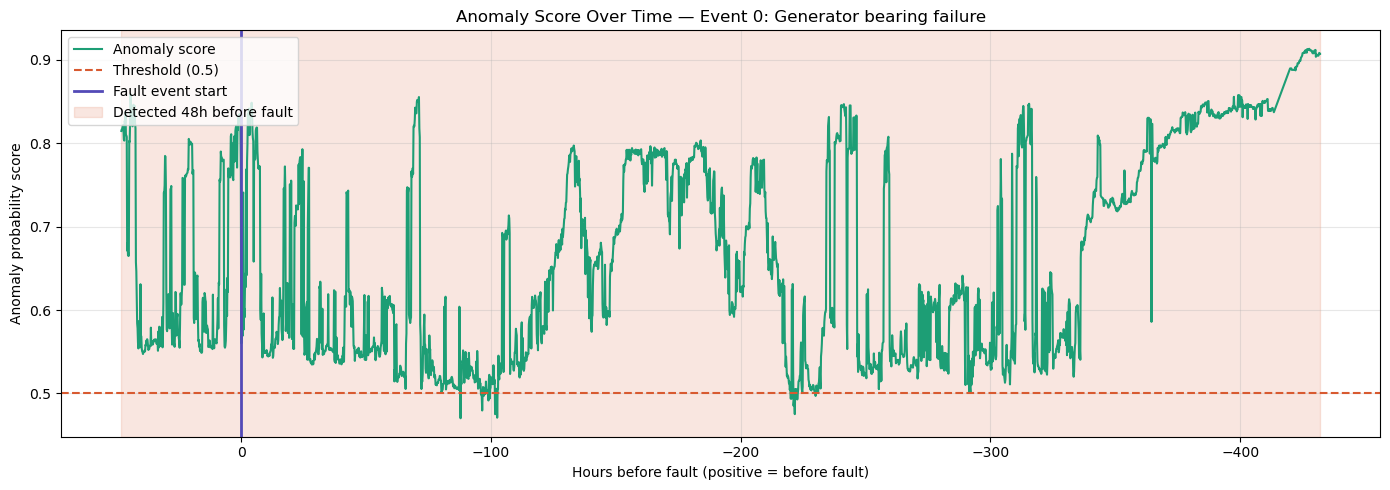

In [25]:
# Plot the model's anomaly probability score over time for one fault event
# A good result shows a low flat score that rises before the fault
# This is the "early warning signal" story

pred_df_plot              = df_pred_eng.copy()
pred_df_plot["score"]     = rf_probs
pred_df_plot["predicted"] = rf_preds

# Load event start times only — don't bring event_label again
# (it already exists in pred_df_plot from the original data load)
event_times = event_info[["event_id", "event_start"]].copy()
event_times["event_start"] = pd.to_datetime(event_times["event_start"])
pred_df_plot["time_stamp"] = pd.to_datetime(pred_df_plot["time_stamp"])

pred_df_plot = pred_df_plot.merge(event_times, on="event_id", how="left")

pred_df_plot["hours_to_event"] = (
    (pred_df_plot["event_start"] - pred_df_plot["time_stamp"])
    .dt.total_seconds() / 3600
)

# Pick the first anomaly event to plot
anomaly_event_ids = pred_df_plot[
    pred_df_plot["event_label"] == "anomaly"
]["event_id"].unique()

if len(anomaly_event_ids) > 0:
    plot_event_id = anomaly_event_ids[0]
    event_plot    = pred_df_plot[
        pred_df_plot["event_id"] == plot_event_id
    ].sort_values("hours_to_event", ascending=False)

    fault_desc = event_info[
        event_info["event_id"] == plot_event_id
    ]["event_description"].values[0]

    fig, ax = plt.subplots(figsize=(14, 5))

    ax.plot(
        event_plot["hours_to_event"],
        event_plot["score"],
        color="#1D9E75", linewidth=1.5, label="Anomaly score"
    )
    ax.axhline(y=0.5, color="#D85A30", linestyle="--",
               linewidth=1.5, label="Threshold (0.5)")
    ax.axvline(x=0, color="#534AB7", linestyle="-",
               linewidth=2, label="Fault event start")

    detected = event_plot[event_plot["score"] >= 0.5]
    if len(detected) > 0:
        first_detection = detected["hours_to_event"].max()
        ax.axvspan(
            detected["hours_to_event"].min(),
            detected["hours_to_event"].max(),
            alpha=0.15, color="#D85A30",
            label=f"Detected {first_detection:.0f}h before fault"
        )
        print(f"First detection: {first_detection:.1f} hours before fault")
    else:
        print("No detection at threshold 0.5 — try lowering threshold")

    ax.set_xlabel("Hours before fault (positive = before fault)")
    ax.set_ylabel("Anomaly probability score")
    ax.set_title(f"Anomaly Score Over Time — Event {plot_event_id}: {fault_desc}")
    ax.legend(loc="upper left")
    ax.grid(alpha=0.3)
    ax.invert_xaxis()
    plt.tight_layout()
    plt.savefig("rf_anomaly_timeseries.png", dpi=150, bbox_inches="tight")
    plt.show()
    # print("Plot saved as rf_anomaly_timeseries.png")

### Summary

In [27]:
print("=" * 55)
print("RANDOM FOREST SUMMARY")
print("=" * 55)
print(f"\nTraining rows:             {len(X_train):,}")
print(f"Prediction rows:           {len(X_pred):,}")
print(f"Features used:             {len(engineered_features)}")
print(f"Trees built:               {rf_model.n_estimators}")
print(f"\nAccuracy:                  {rf_acc*100:.1f}%")

tn, fp, fn, tp = cm.ravel()
precision = tp / max(tp + fp, 1)
recall    = tp / max(tp + fn, 1)
print(f"Precision (of flags, % right): {precision*100:.1f}%")
print(f"Recall    (of faults, % caught): {recall*100:.1f}%")

print(f"\nTop 3 most important features:")
for _, row in importance_df.head(3).iterrows():
    print(f"  {row['feature']:30s} {row['importance']:.4f}")

print("\nSaved plots:")
print("  rf_results.png")
print("  rf_feature_importance.png")
print("  rf_anomaly_timeseries.png")
print("=" * 55)

RANDOM FOREST SUMMARY

Training rows:             1,146,154
Prediction rows:           50,593
Features used:             96
Trees built:               200

Accuracy:                  75.3%
Precision (of flags, % right): 68.6%
Recall    (of faults, % caught): 90.7%

Top 3 most important features:
  reactive_power_27_avg_zscore   0.1645
  sensor_52_avg_zscore           0.1166
  power_29_avg_zscore            0.0983

Saved plots:
  rf_results.png
  rf_feature_importance.png
  rf_anomaly_timeseries.png
